              precision    recall  f1-score   support

           0       0.82      0.92      0.87        25
           1       0.83      0.67      0.74        15

    accuracy                           0.82        40
   macro avg       0.83      0.79      0.80        40
weighted avg       0.83      0.82      0.82        40

IPO_Size: 0.06649230038661753
Subscription: 0.17274452695428327
GMP: 0.1820319013132945
IPO Price: 0.0675186584670671
GMP_to_IPO_Ratio: 0.2556542174576522
Log_IPO_Size: 0.06305064328421704
Subscription_to_GMP: 0.14697017931968484
IPO_Price_to_Size_Ratio: 0.04553757281718356


/tmp/ipython-input-4148003893.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Subscription_tier', data=data, palette='viridis')


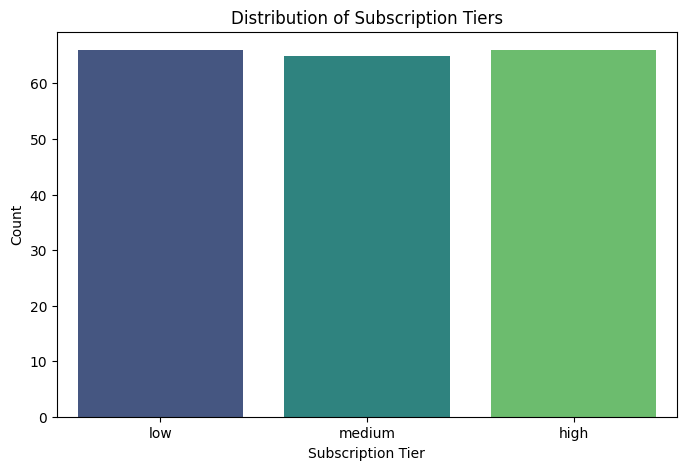

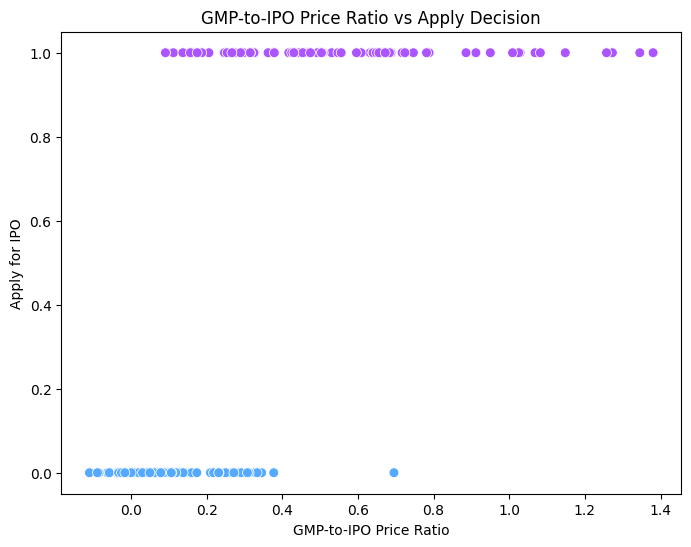

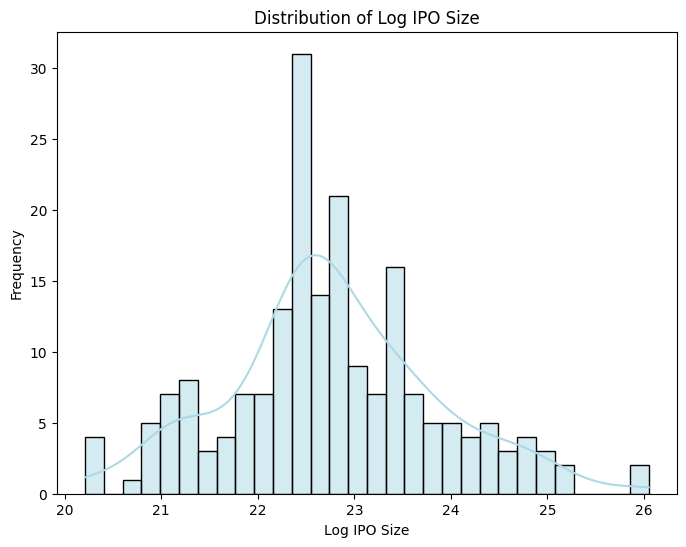

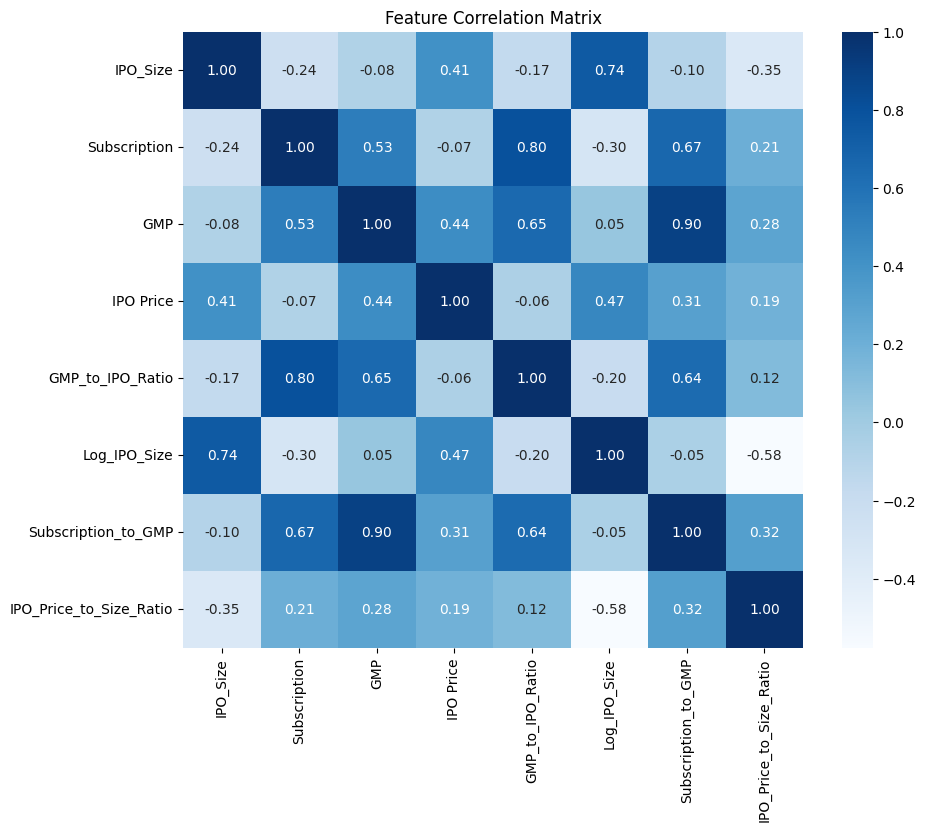

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess the data as in the original code
data = pd.read_csv('/content/IPO Data.csv')
data['IPO_Size'] = data['IPO_Size'].str.replace(r'[₹,]', '', regex=True)
data['IPO_Size'] = data['IPO_Size'].str.replace(r'[Cc]r', '', regex=True).str.strip()
data['IPO_Size'] = data['IPO_Size'].astype(float) * 1e7
data['Subscription'] = data['Subscription'].str.replace('x', '', regex=False).astype(float)
data['IPO Price'] = data['IPO Price'].str.replace(r'[^0-9.]', '', regex=True).astype(float)
data['Listing Price'] = data['Listing Price'].str.extract(r'@(\d+\.\d+)').astype(float)
data['GMP'] = data['GMP'].str.replace(r'₹', '', regex=True).astype(float)
data['apply_for_ipo'] = (data['Listing Price'] > data['IPO Price'] * 1.20).astype(int)
data = data.dropna(subset=['IPO Price', 'Listing Price', 'Subscription', 'GMP', 'IPO_Size'])

# Feature Engineering
data['Subscription_tier'] = pd.qcut(data['Subscription'], q=3, labels=['low', 'medium', 'high'])
data['GMP_to_IPO_Ratio'] = data['GMP'] / data['IPO Price']
data['Log_IPO_Size'] = np.log1p(data['IPO_Size'])
data['Subscription_to_GMP'] = data['Subscription'] * data['GMP']
data['IPO_Price_to_Size_Ratio'] = data['IPO Price'] / data['IPO_Size']

# Define the features and target with engineered features
X = data[['IPO_Size', 'Subscription', 'GMP', 'IPO Price', 'GMP_to_IPO_Ratio', 'Log_IPO_Size', 'Subscription_to_GMP', 'IPO_Price_to_Size_Ratio']]
y = data['apply_for_ipo']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importance
importances = model.feature_importances_
for i, col in enumerate(X.columns):
    print(f'{col}: {importances[i]}')

# --- Visualizations for Feature Mappings ---

# Subscription tier distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Subscription_tier', data=data, palette='viridis')
plt.title('Distribution of Subscription Tiers')
plt.xlabel('Subscription Tier')
plt.ylabel('Count')
plt.show()

# Scatter plot of GMP-to-IPO Ratio vs Apply Probability
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['GMP_to_IPO_Ratio'], y=y, hue=y, palette='cool', s=50)
plt.title('GMP-to-IPO Price Ratio vs Apply Decision')
plt.xlabel('GMP-to-IPO Price Ratio')
plt.ylabel('Apply for IPO')
plt.legend([],[], frameon=False)
plt.show()

# Histogram of Log IPO Size
plt.figure(figsize=(8, 6))
sns.histplot(data['Log_IPO_Size'], kde=True, color="lightblue", bins=30)
plt.title('Distribution of Log IPO Size')
plt.xlabel('Log IPO Size')
plt.ylabel('Frequency')
plt.show()

# Heatmap of Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = data[['IPO_Size', 'Subscription', 'GMP', 'IPO Price', 'GMP_to_IPO_Ratio', 'Log_IPO_Size', 'Subscription_to_GMP', 'IPO_Price_to_Size_Ratio']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Load the new IPO data (assuming already cleaned & numeric)
new_data = pd.read_excel('/content/Mainline Upcoming IPO.xlsx')
import numpy as np

# Clean the Subscription column
new_data['Subscription'] = new_data['Subscription'].str.replace('x', '', regex=False).astype(float)

# Drop rows with missing key values
required_cols = ['IPO_Size', 'Subscription', 'GMP', 'IPO Price']
new_data = new_data.dropna(subset=required_cols)

# --- Feature Engineering ---
new_data['GMP_to_IPO_Ratio'] = new_data['GMP'] / new_data['IPO Price']
new_data['Log_IPO_Size'] = np.log1p(new_data['IPO_Size'])
new_data['Subscription_to_GMP'] = new_data['Subscription'] * new_data['GMP']
new_data['IPO_Price_to_Size_Ratio'] = new_data['IPO Price'] / new_data['IPO_Size']

# --- Prepare feature set for prediction ---
X_new = new_data[['IPO_Size', 'Subscription', 'GMP', 'IPO Price',
                  'GMP_to_IPO_Ratio', 'Log_IPO_Size',
                  'Subscription_to_GMP', 'IPO_Price_to_Size_Ratio']]

# --- Predict ---
new_data['success_probability'] = model.predict_proba(X_new)[:, 1]
new_data['recommend_to_apply'] = (new_data['success_probability'] >= 0.5).astype(int)

# Show results
new_data[['IPO', 'success_probability','recommend_to_apply']]


,IPO,success_probability,recommend_to_apply
0,Scoda Tubes,0.46,0
1,Aegis Vopak Terminals,0.30,0
2,Leela Hotels,0.31,0
3,Belrise Industries,0.71,1
4,Borana Weaves,0.51,1
5,Prostarm Info Systems,0.60,1


In [ ]:
new_data.to_excel('/content/IPO_Prediction_Output.xlsx', index=False)